#### 1. Extract Audio files

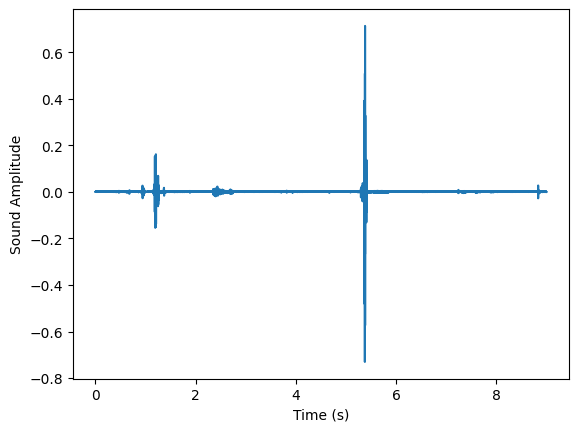

Sample rate: 22050 Hz


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa as lr # Audio analysis
from glob import glob # finds and returns all files items inside a folder

# List all the wav files in the folder
audio_files = glob('heartbeat_audio/set_a/*.wav') # Returns ['audio/song1.wav', 'audio/song2.wav']

# Read in the first audio file, create the time array
# `audio` = array of amplitude values (y-axis)
# `sfreq` = samples per second (e.g., 22050 Hz) (NOT x-axis)
audio, sfreq = lr.load(audio_files[0]) # loads 1 file only
time = np.arange(0, len(audio)) / sfreq
# len(audio) = total number of samples
# sfreq = samples per second
# time = array of time points in seconds (x-axis)

# Plot audio over time
fig, ax = plt.subplots()
ax.plot(time, audio)
ax.set(xlabel='Time (s)', ylabel='Sound Amplitude')
plt.show()
# Get sfreq from first file
print(f"Sample rate: {sfreq} Hz")


#### 2. Seperate normal vs abnormal audio files

Normal files: 31
Abnormal files: 145


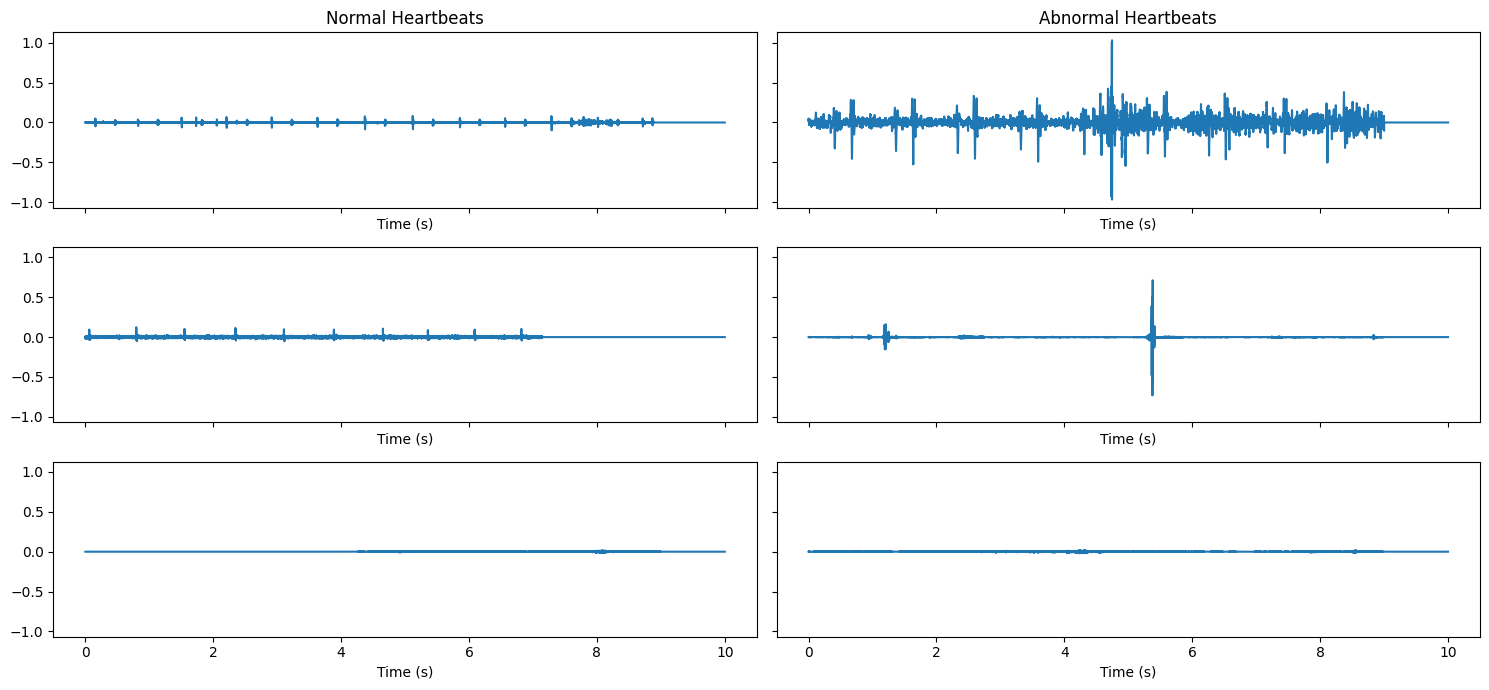

In [7]:
 
# Function to load audio files and separate normal/abnormal
def load_audio_files(file_list, sfreq, max_files=6):
    audio_data = []
    target_length = sfreq * 10  # 10 seconds
    
    for file_path in file_list[:max_files]:
        try:
            audio, _ = lr.load(file_path, sr=sfreq)
            
            # Pad or truncate to same length
            if len(audio) > target_length:
                audio = audio[:target_length]
            else:
                pad_width = target_length - len(audio)
                audio = np.pad(audio, (0, pad_width), constant_values=0)
            
            audio_data.append(audio)
            
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return np.array(audio_data)

# Separate normal and abnormal files based on filename
normal_files = [f for f in audio_files if 'normal' in f]
abnormal_files = [f for f in audio_files if 'normal' not in f]

print(f"Normal files: {len(normal_files)}")
print(f"Abnormal files: {len(abnormal_files)}")

# Load first 3 normal and 3 abnormal
normal_audio = load_audio_files(normal_files, sfreq, max_files=3)
abnormal_audio = load_audio_files(abnormal_files, sfreq, max_files=3)

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(15, 7), sharex=True, sharey=True)

# Calculate time array (based on audio length)
time = np.arange(len(normal_audio[0])) / sfreq

# Stack the normal/abnormal audio
stacked_audio = np.vstack([normal_audio, abnormal_audio])

# Loop through each audio file and plot
for iaudio, ax in zip(stacked_audio, axs.ravel()):
    ax.plot(time, iaudio)
    ax.set_xlabel('Time (s)')

# Set titles
axs[0, 0].set(title="Normal Heartbeats")
axs[0, 1].set(title="Abnormal Heartbeats")
plt.tight_layout()
plt.show()

#### 3. Averages audio

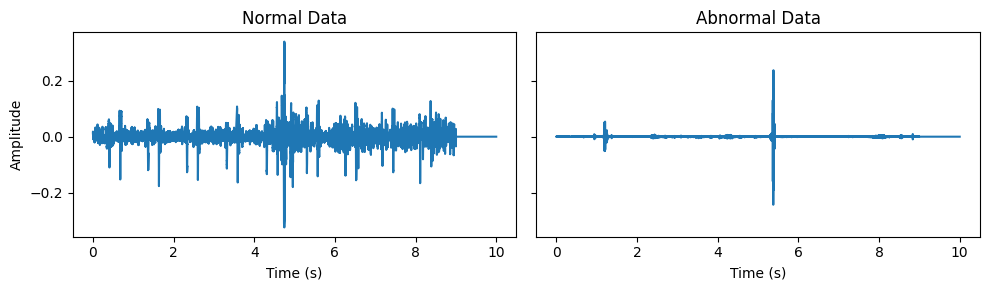

In [9]:
# Calculate mean waveform for normal heartbeats
# axis=0 means average across all files (not axis=1)
mean_normal = np.mean(normal_audio, axis=0)  # FIXED: normal_audio not normal

# Calculate mean waveform for abnormal heartbeats
mean_abnormal = np.mean(abnormal_audio, axis=0)  # FIXED: abnormal_audio not abnormal

# Create side-by-side plots to compare average waveforms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

# Plot average normal heartbeat (S1 and S2 sounds)
ax1.plot(time, mean_normal)
ax1.set(title='Normal Data', xlabel='Time (s)', ylabel='Amplitude')

# Plot average abnormal heartbeat (murmur or extra sounds)
ax2.plot(time, mean_abnormal)
ax2.set(title='Abnormal Data', xlabel='Time (s)')

plt.tight_layout()
plt.show()

#### 4. Train and predict using LinearSVC (Supervised classifier)

In [13]:
# normal_audio shape: (3, 22050) - 3 files, each with 22050 samples
# abnormal_audio shape: (3, 22050)

# Split indices for train/test
n_normal = normal_audio.shape[0]  # Number of normal files (3)
n_abnormal = abnormal_audio.shape[0]  # Number of abnormal files (3)

# For small datasets, use all files for training (no test split)
normal_train_idx = [0, 1]  # Use first 2 normal files for training
normal_test_idx = [2]      # Use last normal file for testing

abnormal_train_idx = [0, 1]  # Use first 2 abnormal files for training
abnormal_test_idx = [2]      # Use last abnormal file for testing

# Create X_train and X_test
X_train = np.vstack([normal_audio[normal_train_idx], 
                     abnormal_audio[abnormal_train_idx]])  # Shape: (4, 22050)

X_test = np.vstack([normal_audio[normal_test_idx], 
                    abnormal_audio[abnormal_test_idx]])  # Shape: (2, 22050)

# Create y_train and y_test
y_train = np.array(['normal'] * len(normal_train_idx) + 
                   ['abnormal'] * len(abnormal_train_idx))
y_test = np.array(['normal'] * len(normal_test_idx) + 
                  ['abnormal'] * len(abnormal_test_idx))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train: {y_train}")
print(f"y_test: {y_test}")


X_train shape: (4, 220500)
X_test shape: (2, 220500)
y_train: ['normal' 'normal' 'abnormal' 'abnormal']
y_test: ['normal' 'abnormal']


In [14]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
 
# Train LinearSVC
model = LinearSVC(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

percent_score = accuracy_score(y_test, predictions)
print(f"Accuracy: {percent_score:.2%}")

Accuracy: 50.00%
